# Retraining Attention-based CNN Yaw Regressor

This notebook recreates and trains the attention-based CNN model for yaw angle regression, with proper handling of the Lambda layers to avoid loading issues.

In [33]:
import keras
keras.config.enable_unsafe_deserialization()

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Add, Lambda, GlobalAveragePooling2D, GlobalMaxPooling2D, Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Multiply, Reshape, Permute, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

## Load the preprocessed dataset

In [34]:
# Load the preprocessed dataset 
with open('../../datasets/regression/data_20000.npy', 'rb') as data, open('../../datasets/regression/label_20000.npy', 'rb') as label:
    dataset = np.load(data)
    print(dataset.shape)
    labels = np.load(label)
    print(labels.shape)

(20000, 128, 128, 3)
(20000, 3)


## Join both the dataset and labels into a single dataframe
This dataset contains images and their `yaw` values

In [35]:
# Extract yaw values only
yaw_labels = labels[:, 1] 
df = pd.DataFrame({
    'image': list(dataset),
    'label': yaw_labels
})

df.head()

,image,label
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",30.915585
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",-70.093781
2,"[[[86, 96, 98], [86, 96, 98], [85, 95, 97], [8...",-59.824131
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",77.033363
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [29, 29, 29...",-60.159260


## Split the dataset into training, testing and validation

In [36]:
validation_split = 0.4

num_train_samples = int((1 - validation_split) * len(df))
testing = df[num_train_samples:]
training = df[:num_train_samples]

num_validation_samples = int(len(testing) * 0.5)
testing = testing[num_validation_samples:]
validation = testing[:num_validation_samples]

print(f'Training: {training.shape[0]}')
print(f'Testing: {testing.shape[0]}')
print(f'Validation: {validation.shape[0]}')

Training: 12000
Testing: 4000
Validation: 4000


## Define training, testing and validation data

In [37]:
# x values
x_training = training['image']
x_testing = testing['image']
x_validation = validation['image']

# y values
y_training = training['label']
y_testing = testing['label']
y_validation = validation['label']

x_training = np.array([np.array(xi).astype(np.float32) for xi in x_training])
y_training = np.array([np.array(yi).astype(np.float32) for yi in y_training])
x_validation = np.array([np.array(xi).astype(np.float32) for xi in x_validation])
y_validation = np.array([np.array(yi).astype(np.float32) for yi in y_validation])
x_testing = np.array([np.array(xi).astype(np.float32) for xi in x_testing])
y_testing = np.array([np.array(yi).astype(np.float32) for yi in y_testing])

# Normalize the data to [0, 1] range
x_training = x_training.astype('float32') / 255.0
x_validation = x_validation.astype('float32') / 255.0
x_testing = x_testing.astype('float32') / 255.0

## Define training callbacks and data augmentation

In [38]:
# Function to ensure directory exists
def ensure_dir_exists(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

# Callbacks for training
def get_callbacks(model_name):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        min_delta=0.001,
        mode='min',
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,
        patience=4,
        min_lr=0.00001
    )
    
    # Make sure experiments directory exists
    output_dir = '../../trained_models'
    ensure_dir_exists(output_dir)
    
    model_checkpoint = ModelCheckpoint(
        f'{output_dir}/{model_name}.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
    
    return [early_stopping, reduce_lr, model_checkpoint]

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(x_training)

## Utility functions for evaluation

In [39]:
# Function to evaluate models
def evaluate_model(model, x_test, y_test, model_name):
    predictions = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print(f"===== {model_name} Evaluation =====")
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R-squared: {r2}')
    
    # Plot predicted vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions)
    plt.xlabel('Actual values')
    plt.ylabel('Predicted values')
    plt.title(f'{model_name} - Predicted vs. Actual values')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Return metrics as dictionary
    return {'model': model_name, 'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

# Function to plot training history
def plot_training_history(history, model_name):
    metrics = pd.DataFrame(history.history)
    
    # Plot loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['loss'], label='Training Loss')
    plt.plot(metrics['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(metrics['mae'], label='Training MAE')
    plt.plot(metrics['val_mae'], label='Validation MAE')
    plt.title(f'{model_name} - Training vs Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the training history plot
    history_dir = '../../model/experiments'
    ensure_dir_exists(history_dir)
    plt.savefig(f'{history_dir}/{model_name}_training_history.png')
    
    plt.show()
    
    # Save training history as JSON for future reference
    history_data = {k: [float(val) for val in v] for k, v in history.history.items()}
    import json
    with open(f'{history_dir}/{model_name}_training_history.json', 'w') as f:
        json.dump(history_data, f)
    
    return metrics

## Improved CNN with Attention Mechanism

This implementation uses a Convolutional Block Attention Module (CBAM) that helps the model focus on the most relevant parts of the face image. The module consists of:

1. **Channel Attention**: Focuses on "what" is important by weighting each channel
2. **Spatial Attention**: Focuses on "where" is important by weighting each spatial location

The key improvement here is to use named functions instead of Lambda layers for better compatibility.

In [40]:
# Define named functions for the operations instead of lambda functions
def mean_channel(x, axis=-1, keepdims=True):
    return K.mean(x, axis=axis, keepdims=keepdims)

def max_channel(x, axis=-1, keepdims=True):
    return K.max(x, axis=axis, keepdims=keepdims)

# Register the custom functions
tf.keras.utils.get_custom_objects().update({'mean_channel': mean_channel})
tf.keras.utils.get_custom_objects().update({'max_channel': max_channel})

In [41]:
def channel_attention(x, ratio=8):
    channel_axis = -1 
    filters = x.shape[channel_axis]
    if filters is None or filters < ratio : 
        mlp_filters_reduced = max(1, int(filters / 2)) if filters else 1 
    else:
        mlp_filters_reduced = filters // ratio
    
    # Shared MLP - defining layers once for potential true sharing if desired later,
    # or use distinct names if not strictly sharing weights yet.
    # For this example, we'll keep them as distinct instances within each path for simplicity of the current fix.
    mlp_reduced_avg = Conv2D(mlp_filters_reduced, kernel_size=1, use_bias=True, activation='relu', name=f'{x.name.split(":")[0]}_channel_mlp_reduced_avg')
    mlp_expanded_avg = Conv2D(filters, kernel_size=1, use_bias=True, name=f'{x.name.split(":")[0]}_channel_mlp_expanded_avg')

    mlp_reduced_max = Conv2D(mlp_filters_reduced, kernel_size=1, use_bias=True, activation='relu', name=f'{x.name.split(":")[0]}_channel_mlp_reduced_max')
    mlp_expanded_max = Conv2D(filters, kernel_size=1, use_bias=True, name=f'{x.name.split(":")[0]}_channel_mlp_expanded_max')
    
    # Average Pooling Path
    avg_pool = GlobalAveragePooling2D(name=f'{x.name.split(":")[0]}_channel_avg_pool')(x)
    avg_pool = Reshape((1, 1, filters), name=f'{x.name.split(":")[0]}_channel_reshape_avg')(avg_pool)
    avg_pool = mlp_reduced_avg(avg_pool)
    avg_pool = mlp_expanded_avg(avg_pool)

    # Max Pooling Path
    max_pool = GlobalMaxPooling2D(name=f'{x.name.split(":")[0]}_channel_max_pool')(x)
    max_pool = Reshape((1, 1, filters), name=f'{x.name.split(":")[0]}_channel_reshape_max')(max_pool)
    max_pool = mlp_reduced_max(max_pool)
    max_pool = mlp_expanded_max(max_pool)

    # --- This is the corrected line ---
    summed_features = Add(name=f'{x.name.split(":")[0]}_channel_add')([avg_pool, max_pool])
    channel_weights = Activation('sigmoid', name=f'{x.name.split(":")[0]}_channel_sigmoid')(summed_features)
    
    return Multiply(name=f'{x.name.split(":")[0]}_channel_multiply')([x, channel_weights])

def spatial_attention(x, kernel_size=7):
    channel_axis = -1  # 'channels_last'

    # Using named functions instead of Lambda layers
    # Create a layer that will apply our custom function
    avg_pool = Lambda(
        mean_channel,
        output_shape=lambda s: (s[0], s[1], s[2], 1),
        arguments={'axis': channel_axis, 'keepdims': True},
        name=f'{x.name.split(":")[0]}_spatial_avg_pool_lambda'
    )(x)

    max_pool = Lambda(
        max_channel,
        output_shape=lambda s: (s[0], s[1], s[2], 1),
        arguments={'axis': channel_axis, 'keepdims': True},
        name=f'{x.name.split(":")[0]}_spatial_max_pool_lambda'
    )(x)

    concat = Concatenate(axis=channel_axis, 
                         name=f'{x.name.split(":")[0]}_spatial_concat')([avg_pool, max_pool])

    attention_feature_map = Conv2D(
        1, kernel_size=kernel_size, strides=1, padding='same',
        activation='sigmoid', use_bias=False,
        name=f'{x.name.split(":")[0]}_spatial_conv_sigmoid'
    )(concat)

    return Multiply(name=f'{x.name.split(":")[0]}_spatial_multiply')([x, attention_feature_map])

def cbam_block(x, ratio=8, kernel_size=7):
    x_channel = channel_attention(x, ratio)
    x_spatial = spatial_attention(x_channel, kernel_size)
    return x_spatial

In [42]:
def create_attention_cnn_model(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)
    
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Fourth convolutional block
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Fully connected layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output for yaw angle
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

## Create and Train the Model

In [43]:
# Create and train attention-based CNN model
attention_model = create_attention_cnn_model()
attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 32)        │          0 │ max_pooling2d_8[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 32)        │          0 │ max_pooling2d_8[… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │          0 │ keras_tensor_187… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │          0 │ keras_tensor_187… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 4)   │        132 │ keras_tensor_187… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 4)   │        132 │ keras_tensor_187… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │        160 │ keras_tensor_187… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │        160 │ keras_tensor_187… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │          0 │ keras_tensor_187… │
│ (Add)               │                   │            │ keras_tensor_187… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 1, 1, 32)  │          0 │ keras_tensor_187… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_187_c… │ (None, 64, 64,    │          0 │ max_pooling2d_8[

 Total params: 9,676,001 (36.91 MB)

 Trainable params: 9,674,081 (36.90 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [44]:
# Train with early stopping and reduced LR on plateau
attention_history = attention_model.fit(
    x_training,
    y_training,
    epochs=25,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('fixed_attention_cnn_yaw_regressor')
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 215ms/step - loss: 762.2013 - mae: 19.6944 - val_loss: 358.9500 - val_mae: 14.7816 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 200ms/step - loss: 147.8274 - mae: 9.2386 - val_loss: 73.1305 - val_mae: 5.8758 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 211ms/step - loss: 107.1233 - mae: 7.8318 - val_loss: 39.5941 - val_mae: 4.4785 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 214ms/step - loss: 85.4279 - mae: 6.9958 - val_loss: 32.8870 - val_mae: 4.2055 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - loss: 76.0486 - mae: 6.6108 - val_loss: 40.1351 - val_mae: 4.7098 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 195ms/step - loss: 71.5637 - mae: 6.3869 - val_loss: 38.9739 - val_mae: 4.5792 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 76s 202ms/step - loss: 68.4743 - mae: 6.2635 - val_loss: 24.7478 - val_m

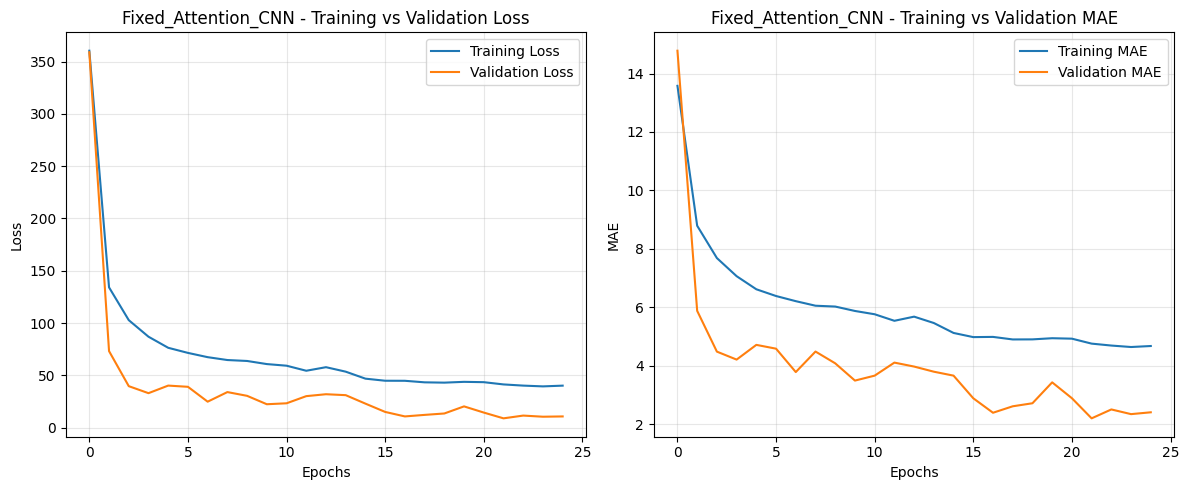

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
===== Fixed_Attention_CNN Evaluation =====
MAE: 2.194061517715454
MSE: 8.81270980834961
RMSE: 2.968620859650085
R-squared: 0.9970301985740662


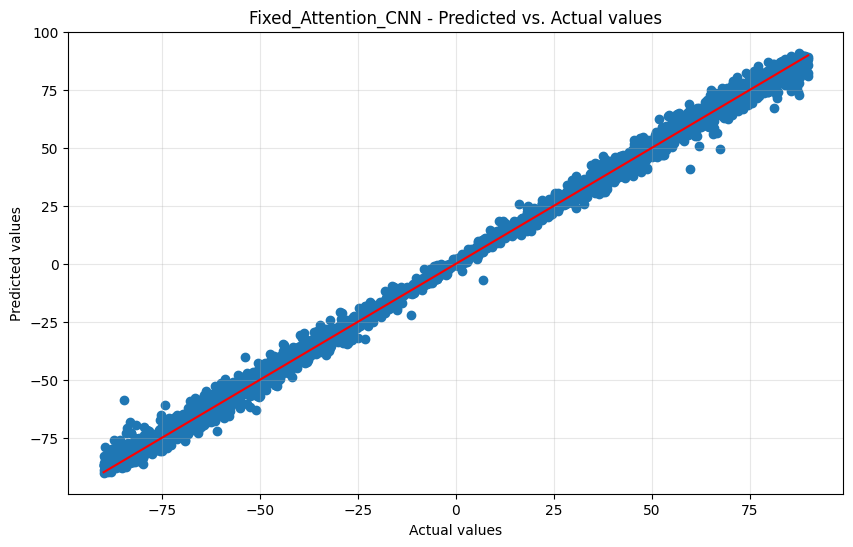

In [45]:
# Plot training history
attention_metrics = plot_training_history(attention_history, 'Fixed_Attention_CNN')

# Evaluate attention-based CNN model
attention_results = evaluate_model(attention_model, x_testing, y_testing, 'Fixed_Attention_CNN')

## Test the model

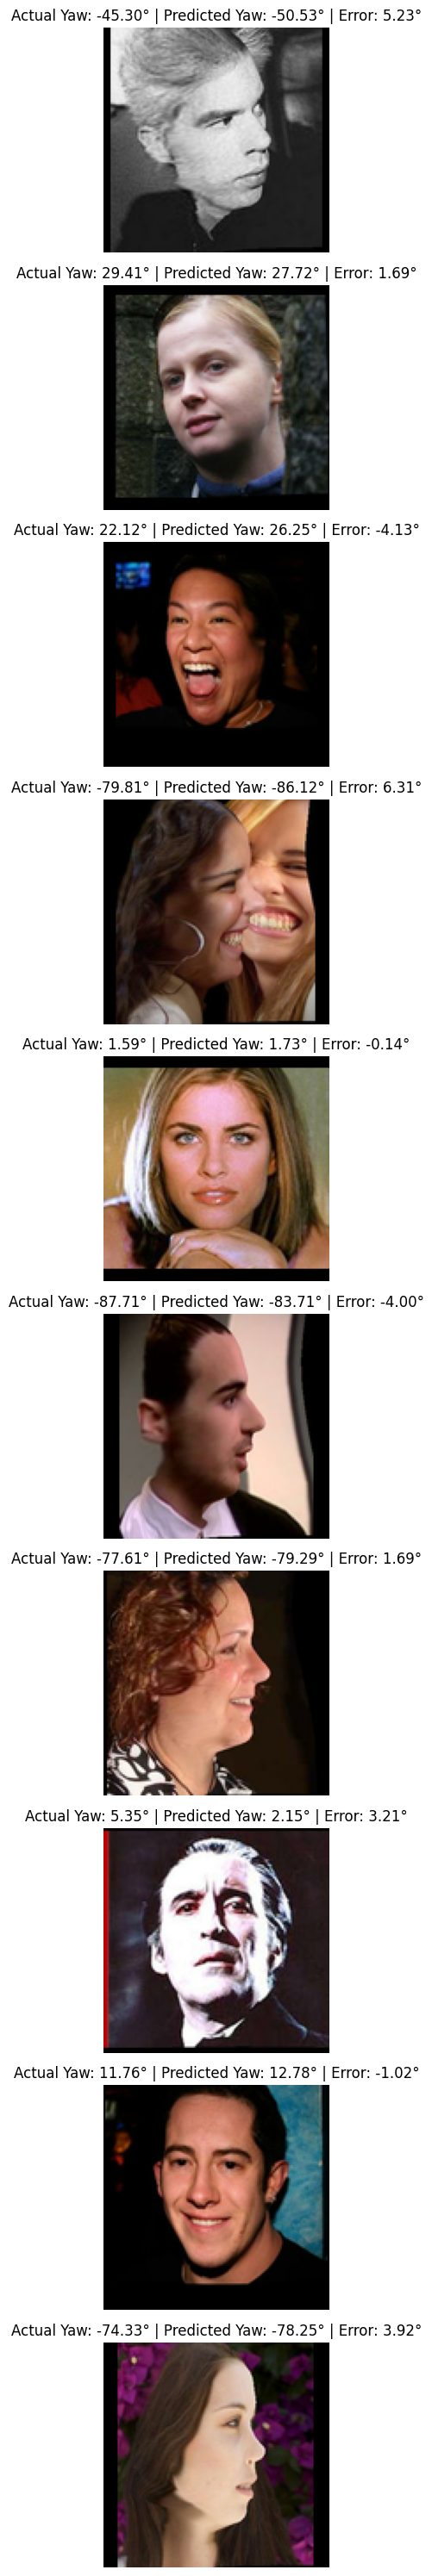

In [47]:
def test_sample_images(num_samples=10):
    sample_indices = np.random.choice(range(len(x_testing)), num_samples)
    
    # Plot each sample with its actual and predicted yaw angle
    plt.figure(figsize=(15, 3*num_samples))
    
    for i, idx in enumerate(sample_indices):
        sample_img = x_testing[idx]
        sample_img_clipped = np.clip(sample_img * 255, 0, 255).astype(np.uint8)
        actual_yaw = y_testing[idx]
        
        # Make prediction
        pred_yaw = attention_model.predict(sample_img.reshape(1, 128, 128, 3), verbose=0)[0][0]
        
        # Plot image with predictions
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(sample_img_clipped)
        plt.title(f'Actual Yaw: {actual_yaw:.2f}° | Predicted Yaw: {pred_yaw:.2f}° | Error: {actual_yaw-pred_yaw:.2f}°')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Test with random samples
test_sample_images()

## Save the model for future use

In [48]:
# Save the model in SavedModel format (more reliable for loading)
model_path = '../../trained_models/fixed_attention_cnn.keras'
attention_model.save(model_path)
print(f"Model saved to {model_path}")

Model saved to ../../trained_models/fixed_attention_cnn.keras


In [49]:
# Try to load the saved model to confirm it works
try:
    model_path = '../../trained_models/fixed_attention_cnn.keras'
    loaded_model = tf.keras.models.load_model(model_path, safe_mode=False)
    print("Model loaded successfully!")

    # Make a test prediction
    test_img = x_testing[0].reshape(1, 128, 128, 3)
    prediction = loaded_model.predict(test_img, verbose=0)[0][0]
    actual = y_testing[0]
    print(f"Test prediction: {prediction:.2f}°, Actual: {actual:.2f}°")
except Exception as e:
    print(f"Error loading SavedModel: {e}")

Model loaded successfully!
Test prediction: -60.65°, Actual: -63.71°


## Test with custom image

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_yaw_from_image(image_path, model):
    # Load the image
    img = cv2.imread(image_path)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert BGR to RGB (OpenCV loads as BGR by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 128x128 (same as your training data)
    img = cv2.resize(img, (128, 128))

    # Normalize to [0, 1] range
    img = img.astype('float32') / 255.0

    # Prepare for prediction (add batch dimension)
    img_batch = np.expand_dims(img, axis=0)

    # Make prediction
    yaw_prediction = model.predict(img_batch, verbose=0)[0][0]

    # Display image with prediction
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Predicted Yaw Angle: {yaw_prediction:.2f}°")
    plt.axis('off')
    plt.show()

    return yaw_prediction

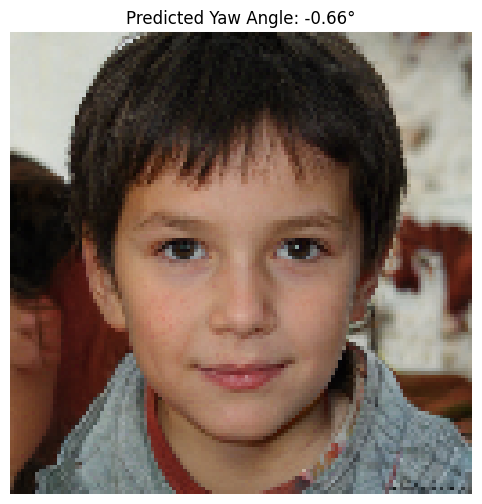

Predicted yaw angle: -0.66°


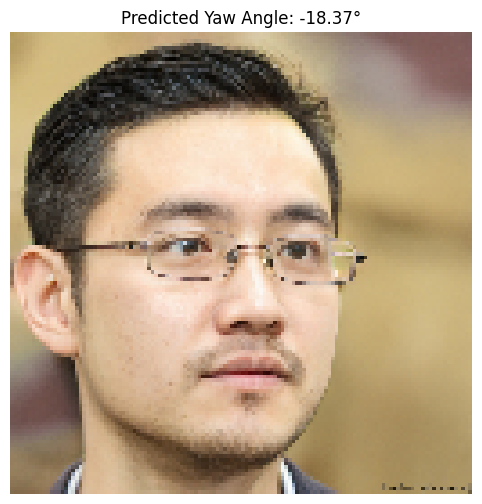

Predicted yaw angle: -18.37°


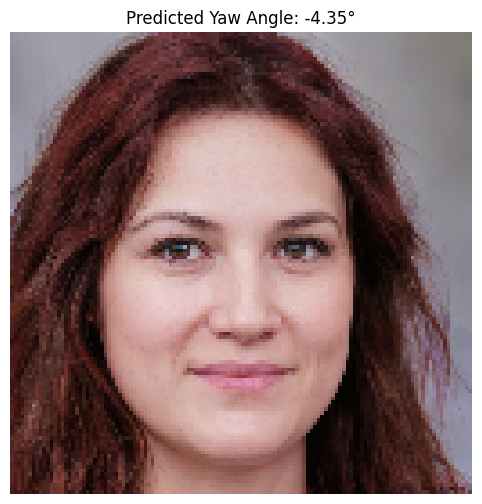

Predicted yaw angle: -4.35°


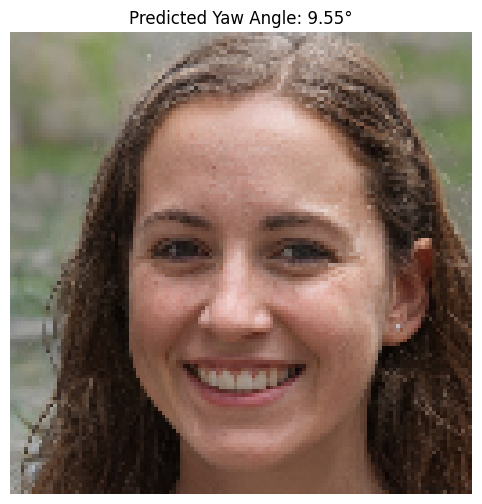

Predicted yaw angle: 9.55°


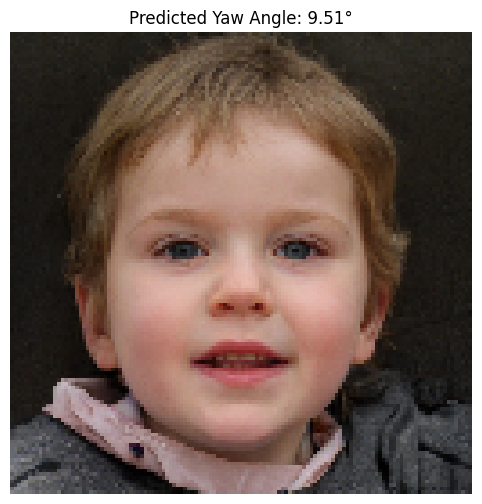

Predicted yaw angle: 9.51°


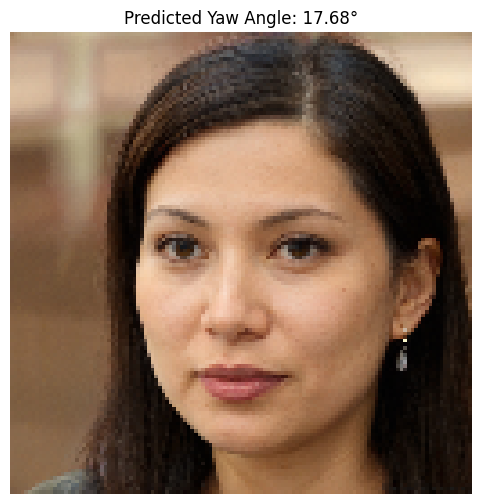

Predicted yaw angle: 17.68°


In [56]:
import glob
import os

folder_path = './'
jpg_files = glob.glob(os.path.join(folder_path, '*.jpeg'))

for file in jpg_files:
    filename = os.path.basename(file)
    # print(filename)
    
    #custom_image_path = 's.jpg'
    yaw = predict_yaw_from_image(filename, loaded_model)
    print(f"Predicted yaw angle: {yaw:.2f}°")